In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


CUDA available: True
CUDA version: 12.1
Device count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
import pandas as pd
import os
import sys
from pathlib import Path
import torch

In [5]:
%load_ext autoreload
%autoreload 2

In [7]:
# Display all columns
pd.set_option('display.max_columns', None)

# Display all rows
pd.set_option('display.max_rows', None)

# Set the width to show all content in each cell
pd.set_option('display.width', None)

# Set the max string length to display
pd.set_option('display.max_colwidth', None)


In [9]:
sys.path.append('C:/Users/rishe/Dissertation')

In [11]:
EXP_ID = f'exp_1_baseline_30_days_window'
DATA_PATH = f'C:/Users/rishe/Dissertation/data/processed_rain.parquet'

In [13]:
df_long = pd.read_parquet(DATA_PATH)

In [15]:
df_long.shape

(4741665, 11)

In [17]:
df_long['station_id'].nunique()

293

### data pre-processing

In [21]:
df_long.head()

,station_id,date,year,month,day,day_of_year,rainfall,lat,lon,district,station_type
0,AKRIGANJ,1901-01-01,1901,1,1,1,4.1,NaN,NaN,MURSHIDABAD,None
1,AKRIGANJ,1901-01-02,1901,1,2,2,3.3,NaN,NaN,MURSHIDABAD,None
2,AKRIGANJ,1901-01-03,1901,1,3,3,0.3,NaN,NaN,MURSHIDABAD,None
3,AKRIGANJ,1901-01-04,1901,1,4,4,0.3,NaN,NaN,MURSHIDABAD,None
4,AKRIGANJ,1901-01-05,1901,1,5,5,0.0,NaN,NaN,MURSHIDABAD,None


In [23]:
df_long.isna().sum()

station_id            0
date                  0
year                  0
month                 0
day                   0
day_of_year           0
rainfall         782517
lat              116514
lon              116514
district              0
station_type    2977122
dtype: int64

In [25]:
df_long = df_long.dropna(subset=['rainfall'])

In [27]:
station_summary = df_long.groupby('station_id').agg(
    data_available_in_days=('rainfall', 'count'),
    rainy_days=('rainfall', lambda x: (x > 0).sum())
).reset_index()

In [29]:
station_summary

,station_id,data_available_in_days,rainy_days
0,AKRIGANJ,15713,3599
1,ALGARAH,13575,5625
2,ALIPUR,43752,14650
3,ALIPURDUAR,34602,11853
4,ALIPURDUAR(CWC),4937,1847
5,ALSHA,851,164
6,AMBIKANAGAR,4901,1223
7,AMLAGORA,18088,4391
8,AMTA,23741,6478
9,AMTALA,8939,1809


In [31]:
station_summary['rainy_days'].sum()

1121149

### Data splits

In [34]:
from utils.data_utils.data_helper_utils import temporal_split

In [36]:
df_train, df_val, df_test = temporal_split(df_long)

### Dataset preparation

In [39]:
from utils.data_utils.dataset_files.dataset_with_meta_features import RainfallWindowDataset

In [41]:
H = 1
L = 30
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [43]:
device

device(type='cuda')

In [45]:
train_ds = RainfallWindowDataset(
    df_train,
    window_length=L,
    horizon=H,
    min_days_per_station=L + H
)

val_ds = RainfallWindowDataset(
    df_val,
    window_length=L,
    horizon=H,
    min_days_per_station=L + H
)

test_ds = RainfallWindowDataset(
    df_test,
    window_length=L,
    horizon=H,
    min_days_per_station=L + H
)


### training

In [48]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Compiled with CUDA:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())


Torch version: 2.5.1
CUDA available: True
Compiled with CUDA: 12.1
GPU count: 1


In [50]:
DATA_PATH

'C:/Users/rishe/Dissertation/data/processed_rain.parquet'

In [52]:
model_save_path = f"C:/Users/rishe/Dissertation/experiments/saved_models/{EXP_ID}"
log_save_path = f"C:/Users/rishe/Dissertation/experiments/logs/{EXP_ID}"
log_save_path

'C:/Users/rishe/Dissertation/experiments/logs/exp_1_baseline_30_days_window'

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [56]:
from models.baseline_lstm import *

In [58]:
model = RainfallLSTM(
    input_dim=train_ds.X.shape[-1],
    hidden_dim=128
).to(device)


In [60]:
model = train_model(
    train_ds=train_ds,
    val_ds=val_ds,
    model=model,
    device=device,
    batch_size=64,
    epochs=10,
    save_dir=model_save_path,
    log_dir = log_save_path,
    experiment_name=EXP_ID
)

2026-02-05 23:23:50 | INFO | Starting training
2026-02-05 23:23:50 | INFO | Device: cuda


Epochs:  10%|█         | 1/10 [02:30<22:36, 150.68s/it, train=235.3095, val=247.6964]

2026-02-05 23:26:22 | INFO | Epoch 001 | Train Loss: 235.309476 | Val Loss: 247.696354
2026-02-05 23:26:22 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_1_baseline_30_days_window\epoch_1.pt


Epochs:  20%|██        | 2/10 [04:57<19:49, 148.68s/it, train=234.1747, val=246.6397]

2026-02-05 23:28:49 | INFO | Epoch 002 | Train Loss: 234.174734 | Val Loss: 246.639682
2026-02-05 23:28:49 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_1_baseline_30_days_window\epoch_2.pt


...

2026-02-05 23:43:50 | INFO | Epoch 008 | Train Loss: 233.483607 | Val Loss: 246.835479
2026-02-05 23:43:50 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_1_baseline_30_days_window\epoch_8.pt


Epochs:  90%|█████████ | 9/10 [22:28<02:29, 149.70s/it, train=233.3617, val=247.7194]

2026-02-05 23:46:20 | INFO | Epoch 009 | Train Loss: 233.361701 | Val Loss: 247.719429
2026-02-05 23:46:20 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_1_baseline_30_days_window\epoch_9.pt


Epochs: 100%|██████████| 10/10 [25:03<00:00, 150.33s/it, train=233.4392, val=246.9242]

2026-02-05 23:48:55 | INFO | Epoch 010 | Train Loss: 233.439163 | Val Loss: 246.924234
2026-02-05 23:48:55 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_1_baseline_30_days_window\epoch_10.pt
2026-02-05 23:48:55 | INFO | Training completed


In [64]:

test_metrics = evaluate_on_test(
    test_ds,
    model,
    device 
)

print(test_metrics)

2026-02-05 23:49:44 | INFO | Overall Test Metrics
2026-02-05 23:49:44 | INFO | RMSE: 15.8226
2026-02-05 23:49:44 | INFO | MAE: 6.8734
2026-02-05 23:49:44 | INFO | Bias: 0.1603
2026-02-05 23:49:44 | INFO | NRMSE: 2.8266
2026-02-05 23:49:44 | INFO | MONSOON RMSE: 23.0335
2026-02-05 23:49:44 | INFO | NON_MONSOON RMSE: 8.7157
{'RMSE': 15.822558, 'MAE': 6.8734303, 'Bias': 0.16031171, 'NRMSE': 2.826570032077639, 'monsoon_RMSE': 23.03346, 'non_monsoon_RMSE': 8.715739}


### Baseline evaluation

In [66]:
from utils.metric_utils.metrics import *

In [68]:
ckpt_path = f"{model_save_path}/epoch_9.pt"  

In [70]:
ckpt_path

'C:/Users/rishe/Dissertation/experiments/saved_models/exp_1_baseline_30_days_window/epoch_9.pt'

In [72]:
checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()


C:\Users\rishe\AppData\Local\Temp\ipykernel_13440\3928164772.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location=device)


RainfallLSTM(
  (lstm): LSTM(7, 128, batch_first=True)
  (head): Linear(in_features=128, out_features=1, bias=True)
)

In [74]:
df_eval = collect_test_predictions(
    test_ds=test_ds,
    model=model,
    device=device
)

df_eval.head()


,y,yhat,month,station_id,lat,lon
0,0.0,7.731314,8,AKRIGANJ,NaN,NaN
1,0.0,8.279305,8,AKRIGANJ,NaN,NaN
2,0.0,7.707010,8,AKRIGANJ,NaN,NaN
3,0.0,7.368277,8,AKRIGANJ,NaN,NaN
4,4.8,7.212917,8,AKRIGANJ,NaN,NaN


#### Overall evaluation metrics

In [77]:
overall_metrics = {
    "RMSE": rmse(df_eval.y.values, df_eval.yhat.values),
    "MAE": mae(df_eval.y.values, df_eval.yhat.values),
    "Bias": bias(df_eval.y.values, df_eval.yhat.values),
    "NRMSE": nrmse(df_eval.y.values, df_eval.yhat.values),
}

pd.DataFrame(overall_metrics, index=["Overall"])


,RMSE,MAE,Bias,NRMSE
Overall,15.846863,6.696569,-0.197792,2.830912


In [117]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# prediction error
df_eval["error"] = df_eval["y"] - df_eval["yhat"]

# masks
rainy_mask = df_eval["y"] > 0
non_rainy_mask = df_eval["y"] == 0

monsoon_months = [6, 7, 8, 9]
non_monsoon_months = [1, 2, 3, 4, 5, 10, 11, 12]

monsoon_mask = df_eval["month"].isin(monsoon_months)
non_monsoon_mask = df_eval["month"].isin(non_monsoon_months)


In [119]:
non_rainy_mask.sum()/df_eval.shape[0]

0.7156859730578303

In [121]:
(df_eval['error']).describe(percentiles = [0.1,.2,.25,.3,.4,.5,.6,.7,.75,.8,.9,.95,.96,.97,.98,.99])

count    585402.000000
mean          0.197792
std          15.845640
min         -62.804787
10%          -9.318119
20%          -6.533295
25%          -5.196527
30%          -4.005273
40%          -1.952622
50%          -0.785189
60%          -0.402830
70%          -0.147967
75%          -0.034939
80%           0.050267
90%           7.182401
95%          21.739637
96%          27.146000
97%          34.594497
98%          46.012561
99%          68.329878
max         612.652100
Name: error, dtype: float64

#### Seasonal evaluation

In [123]:
monsoon_months = [6, 7, 8, 9]
non_monsoon_months = [1, 2, 3, 4, 5, 10, 11, 12]

df_monsoon = seasonal_subset(df_eval, monsoon_months)
df_non_monsoon = seasonal_subset(df_eval, non_monsoon_months)

seasonal_metrics = pd.DataFrame({
    "Monsoon": {
        "RMSE": rmse(df_monsoon.y, df_monsoon.yhat),
        "MAE": mae(df_monsoon.y, df_monsoon.yhat),
        "Bias": bias(df_monsoon.y, df_monsoon.yhat),
    },
    "Non-Monsoon": {
        "RMSE": rmse(df_non_monsoon.y, df_non_monsoon.yhat),
        "MAE": mae(df_non_monsoon.y, df_non_monsoon.yhat),
        "Bias": bias(df_non_monsoon.y, df_non_monsoon.yhat),
    }
}).T

seasonal_metrics


,RMSE,MAE,Bias
Monsoon,23.079325,13.090454,-0.419241
Non-Monsoon,8.711857,2.716992,-0.059962


#### Per station performance table

In [126]:
df_station_metrics = stationwise_metrics(df_eval)

df_station_metrics.head()


C:\Users/rishe/Dissertation\utils\metric_utils\metrics.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,station_id,RMSE,MAE,Bias,Count
0,AKRIGANJ,15.782374,6.420414,-0.878900,2327.0
1,ALGARAH,15.448892,6.982583,-0.398009,2007.0
2,ALIPUR,13.640985,5.988367,-0.223593,6533.0
3,ALIPURDUAR,27.794872,11.368061,-2.982877,5161.0
4,ALIPURDUAR(CWC),37.420509,13.393710,-5.290635,711.0


In [200]:
df_station_metrics

,station_id,RMSE,MAE,Bias,Count
0,AKRIGANJ,15.782374,6.420414,-0.878900,2327.0
1,ALGARAH,15.448892,6.982583,-0.398009,2007.0
2,ALIPUR,13.640985,5.988367,-0.223593,6533.0
3,ALIPURDUAR,27.794872,11.368061,-2.982877,5161.0
4,ALIPURDUAR(CWC),37.420509,13.393710,-5.290635,711.0
5,ALSHA,8.409146,2.545303,-0.672590,98.0
6,AMBIKANAGAR,9.093360,4.388759,0.796992,706.0
7,AMLAGORA,12.671866,5.966546,0.007772,2684.0
8,AMTA,14.992837,7.822612,0.498796,3532.0
9,AMTALA,11.785336,5.811895,0.343718,1311.0


In [128]:
df_station_metrics.describe()

,RMSE,MAE,Bias,Count
count,283.000000,283.000000,283.000000,283.000000
mean,13.842510,6.456441,-0.033891,2068.558304
std,6.646449,2.895016,1.601252,1583.197919
min,0.058866,0.051670,-7.152454,2.000000
25%,10.215177,4.926177,-0.359112,799.500000
50%,12.349029,5.657100,0.327443,1747.000000
75%,16.305348,7.933917,0.763593,2916.000000
max,40.842129,20.653906,6.505141,6533.000000


#### Month-wise RMSE

In [131]:
df_long.month.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int64)

In [133]:
df_eval.tail()

,y,yhat,month,station_id,lat,lon,error
585397,3.6,14.802826,6,VISHNUPUR,23.08,87.32,-11.202826
585398,16.4,8.889038,6,VISHNUPUR,23.08,87.32,7.510962
585399,2.4,12.149276,6,VISHNUPUR,23.08,87.32,-9.749275
585400,5.0,8.068067,6,VISHNUPUR,23.08,87.32,-3.068067
585401,3.8,9.450118,6,VISHNUPUR,23.08,87.32,-5.650118


C:\Users\rishe\AppData\Local\Temp\ipykernel_13440\803231696.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: rmse(g.y.values, g.yhat.values))


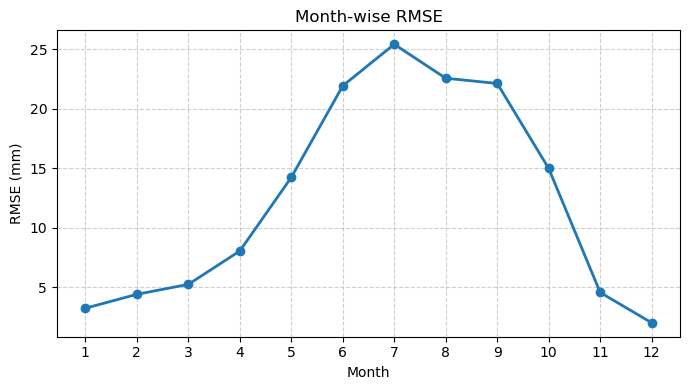

In [198]:
import numpy as np
import matplotlib.pyplot as plt

# compute month-wise RMSE
month_rmse = (
    df_eval
    .groupby("month")
    .apply(lambda g: rmse(g.y.values, g.yhat.values))
    .sort_index()
)

# plot
plt.figure(figsize=(7, 4))
plt.plot(
    month_rmse.index,
    month_rmse.values,
    marker="o",
    linewidth=2
)

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("RMSE (mm)")
plt.title("Month-wise RMSE")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [135]:
# baseline 1: predict zero
yhat_zero = np.zeros_like(df_eval.y)

# baseline 2: predict mean rainfall
yhat_mean = np.full_like(df_eval.y, df_eval.y.mean())

baseline_table = pd.DataFrame({
    "Model": {
        "RMSE": rmse(df_eval.y, df_eval.yhat),
        "MAE": mae(df_eval.y, df_eval.yhat),
    },
    "Zero Predictor": {
        "RMSE": rmse(df_eval.y, yhat_zero),
        "MAE": mae(df_eval.y, yhat_zero),
    },
    "Mean Predictor": {
        "RMSE": rmse(df_eval.y, yhat_mean),
        "MAE": mae(df_eval.y, yhat_mean),
    },
}).T

baseline_table


,RMSE,MAE
Model,15.846863,6.696569
Zero Predictor,18.398365,5.597794
Mean Predictor,17.526112,8.638353


#### Error distribution

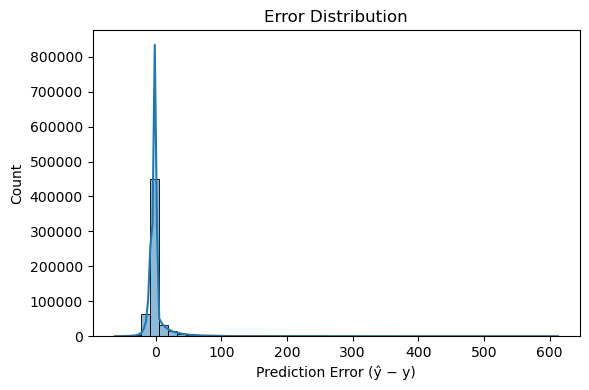

In [141]:
errors = df_eval.error

plt.figure(figsize=(6, 4))
sns.histplot(errors, bins=50, kde=True)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution")
plt.tight_layout()
plt.show()


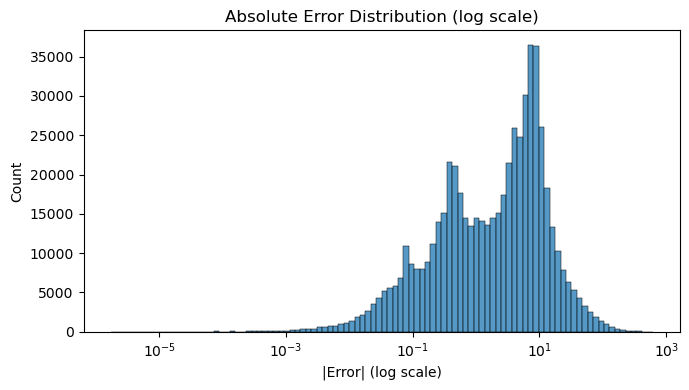

In [145]:
plt.figure(figsize=(7, 4))

sns.histplot(
    np.abs(df_eval["error"]) + 1e-6,
    bins=100,
    log_scale=True
)

plt.xlabel("|Error| (log scale)")
plt.title("Absolute Error Distribution (log scale)")
plt.tight_layout()
plt.show()


In [147]:
def error_stats(series):
    return {
        "Mean Error (Bias)": np.mean(series),
        "MAE": np.mean(np.abs(series)),
        "RMSE": np.sqrt(np.mean(series**2)),
        "Count": len(series)
    }

error_table = pd.DataFrame({
    "Rainy Days (y > 0)": error_stats(df_eval.loc[rainy_mask, "error"]),
    "Non-Rainy Days (y = 0)": error_stats(df_eval.loc[non_rainy_mask, "error"]),
}).T

error_table


,Mean Error (Bias),MAE,RMSE,Count
Rainy Days (y > 0),8.653096,15.547951,28.421993,166438.0
Non-Rainy Days (y = 0),-3.161169,3.180259,5.474777,418964.0


### Error histogram - rainy vs non-rainy days

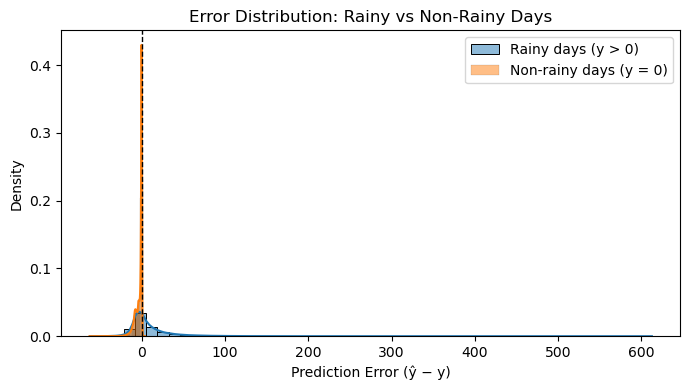

In [149]:
plt.figure(figsize=(7, 4))

sns.histplot(
    df_eval.loc[rainy_mask, "error"],
    bins=50,
    kde=True,
    color="tab:blue",
    label="Rainy days (y > 0)",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_rainy_mask, "error"],
    bins=50,
    kde=True,
    color="tab:orange",
    label="Non-rainy days (y = 0)",
    stat="density",
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution: Rainy vs Non-Rainy Days")
plt.legend()
plt.tight_layout()
plt.show()


In [153]:
df_eval["pred_rain"] = df_eval["yhat"] > 0
df_eval["true_rain"] = df_eval["y"] > 0

pd.crosstab(
    df_eval["true_rain"],
    df_eval["pred_rain"],
    normalize="index"
)


pred_rain,False,True
true_rain,,
False,0.100462,0.899538
True,0.004032,0.995968


### conditional rmse

In [157]:
def conditional_rmse(mask, name):
    e = df_eval.loc[mask]
    return {
        "Regime": name,
        "RMSE": rmse(e.y, e.yhat),
        "MAE": mae(e.y, e.yhat),
        "Bias": bias(e.y, e.yhat),
        "Count": len(e)
    }

pd.DataFrame([
    conditional_rmse(df_eval.y == 0, "Non-rainy"),
    conditional_rmse((df_eval.y > 0) & (df_eval.y <= 10), "Light rain"),
    conditional_rmse((df_eval.y > 10) & (df_eval.y <= 50), "Moderate rain"),
    conditional_rmse(df_eval.y > 50, "Heavy rain"),
])


,Regime,RMSE,MAE,Bias,Count
0,Non-rainy,5.474777,3.180259,3.161169,418964
1,Light rain,8.919576,6.608468,5.529953,83490
2,Moderate rain,17.130159,13.695995,-11.697448,67003
3,Heavy rain,82.355698,70.138367,-70.124535,15945


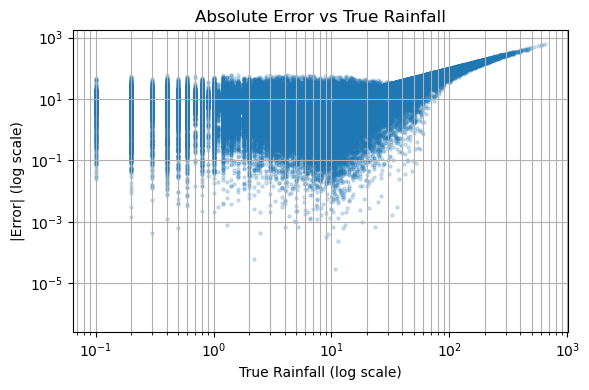

In [159]:
plt.figure(figsize=(6, 4))

plt.scatter(
    df_eval["y"],
    np.abs(df_eval["error"]),
    alpha=0.2,
    s=5
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("True Rainfall (log scale)")
plt.ylabel("|Error| (log scale)")
plt.title("Absolute Error vs True Rainfall")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


#### Monsoon vs non-monsoon

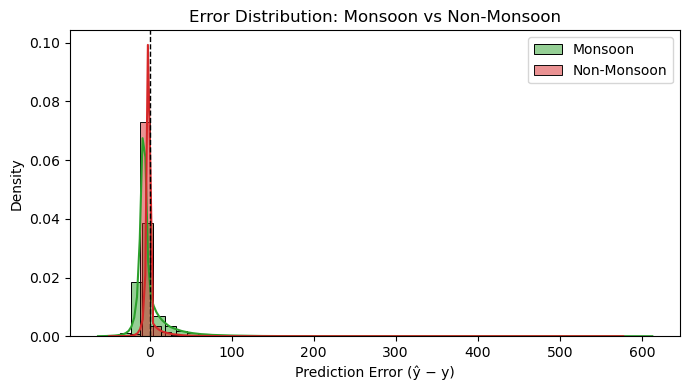

In [162]:
plt.figure(figsize=(7, 4))

sns.histplot(
    df_eval.loc[monsoon_mask, "error"],
    bins=50,
    kde=True,
    color="tab:green",
    label="Monsoon",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_monsoon_mask, "error"],
    bins=50,
    kde=True,
    color="tab:red",
    label="Non-Monsoon",
    stat="density",
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution: Monsoon vs Non-Monsoon")
plt.legend()
plt.tight_layout()
plt.show()


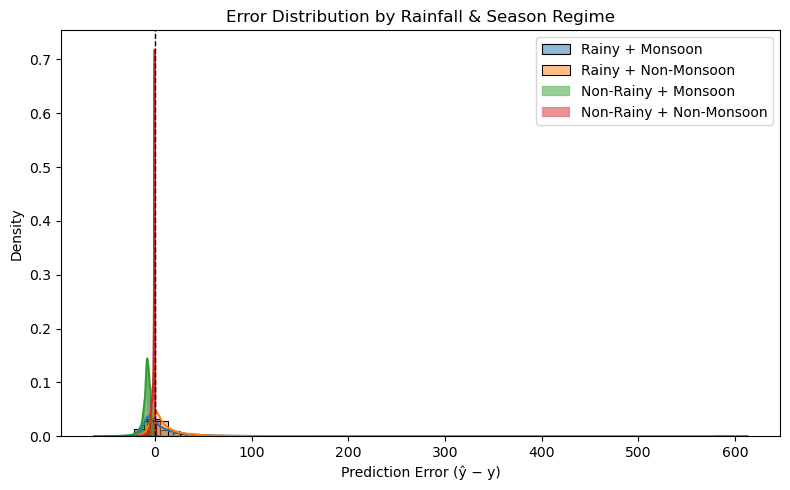

In [164]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_eval.loc[rainy_mask & monsoon_mask, "error"],
    bins=50,
    kde=True,
    label="Rainy + Monsoon",
    stat="density",
)

sns.histplot(
    df_eval.loc[rainy_mask & non_monsoon_mask, "error"],
    bins=50,
    kde=True,
    label="Rainy + Non-Monsoon",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_rainy_mask & monsoon_mask, "error"],
    bins=50,
    kde=True,
    label="Non-Rainy + Monsoon",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_rainy_mask & non_monsoon_mask, "error"],
    bins=50,
    kde=True,
    label="Non-Rainy + Non-Monsoon",
    stat="density",
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution by Rainfall & Season Regime")
plt.legend()
plt.tight_layout()
plt.show()


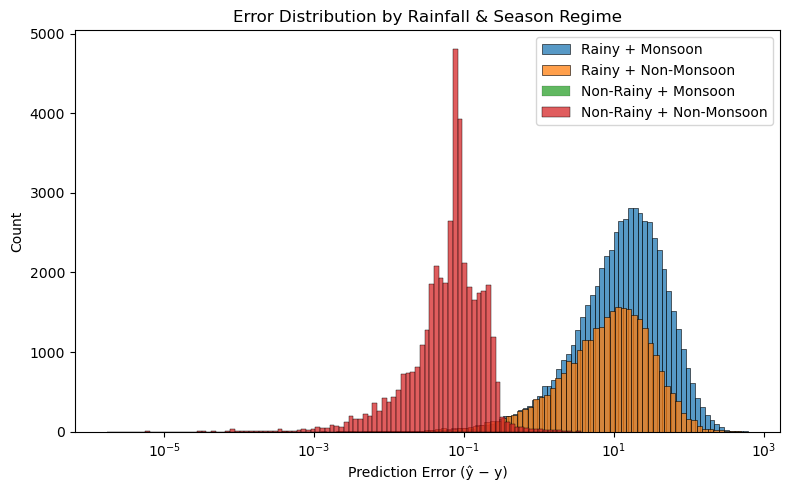

In [192]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_eval.loc[rainy_mask & monsoon_mask, "error"] +1e-6,
    bins=100,
    log_scale=True,
    label="Rainy + Monsoon"
)

sns.histplot(
    df_eval.loc[rainy_mask & non_monsoon_mask, "error"] +1e-6,
    bins=100,
    log_scale=True,
    label="Rainy + Non-Monsoon"
)

sns.histplot(
    df_eval.loc[non_rainy_mask & monsoon_mask, "error"] +1e-6,
    bins=100,
    log_scale=True,
    label="Non-Rainy + Monsoon"
)

sns.histplot(
    df_eval.loc[non_rainy_mask & non_monsoon_mask, "error"] +1e-6,
    bins=100,
    log_scale=True,
    label="Non-Rainy + Non-Monsoon"
)

plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution by Rainfall & Season Regime")
plt.legend()
plt.tight_layout()
plt.show()


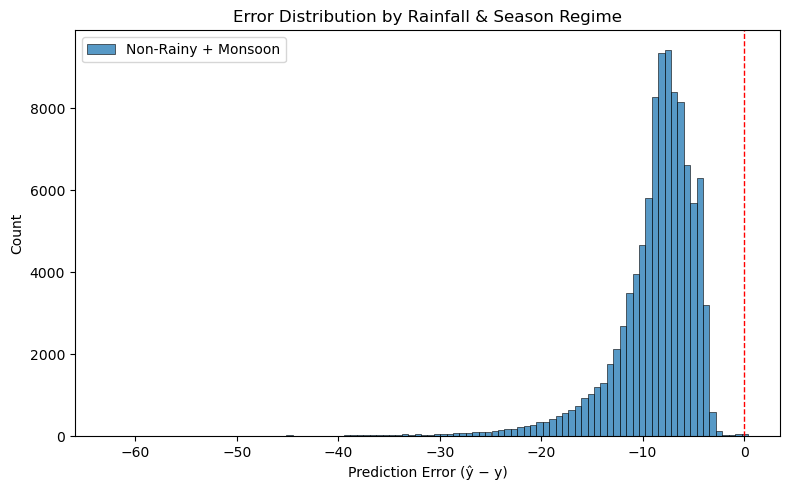

In [188]:
plt.figure(figsize=(8, 5))
sns.histplot(
    df_eval.loc[non_rainy_mask & monsoon_mask, "error"] +1e-6,
    bins=100,
    # log_scale = True,
    label="Non-Rainy + Monsoon"
)

plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution by Rainfall & Season Regime")
plt.legend()
plt.tight_layout()
plt.show()

### Summary table

In [194]:
rows = []

def add_row(name, mask):
    e = df_eval.loc[mask, "error"]
    rows.append({
        "Regime": name,
        "Bias": np.mean(e),
        "MAE": np.mean(np.abs(e)),
        "RMSE": np.sqrt(np.mean(e**2)),
        "Samples": len(e)
    })

add_row("Rainy + Monsoon", rainy_mask & monsoon_mask)
add_row("Rainy + Non-Monsoon", rainy_mask & non_monsoon_mask)
add_row("Non-Rainy + Monsoon", non_rainy_mask & monsoon_mask)
add_row("Non-Rainy + Non-Monsoon", non_rainy_mask & non_monsoon_mask)

df_error_regimes = pd.DataFrame(rows)
df_error_regimes


,Regime,Bias,MAE,RMSE,Samples
0,Rainy + Monsoon,8.145941,16.513309,29.796783,123036
1,Rainy + Non-Monsoon,10.090781,12.811357,24.102203,43402
2,Non-Rainy + Monsoon,-8.943016,8.943066,10.113179,101542
3,Non-Rainy + Non-Monsoon,-1.311580,1.336761,2.616045,317422
